
### **Importing libraries for loading the data,visualization and eda**

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

Getting all the feature variables and the scenario label

In [134]:
data = pd.read_csv('FireProject.csv',usecols=['MQ-5','MQ-135','MQ-2','MQ-3','TD','SCENARIO'])

Getting the statistics on each feature column

In [135]:
data.describe()

,MQ-5,MQ-135,MQ-2,MQ-3,TD
count,776.000000,776.000000,776.000000,776.000000,776.000000
mean,46.813235,6.160090,10.810580,0.002745,0.758119
std,181.640381,3.820815,10.258363,0.007972,0.781619
min,0.070000,1.920000,0.960000,0.000000,0.000000
25%,0.190000,4.240000,3.580000,0.000000,0.300000
50%,1.080000,4.340000,6.090000,0.000000,0.500000
75%,11.262500,6.810000,17.045000,0.000000,0.900000
max,1532.230000,23.450000,56.790000,0.070000,3.100000


Encoding scenario label column

In [158]:
data['scenario_label_cat'] = data['SCENARIO'].astype('category')
y=  data['SCENARIO']
data['scenario_label_cat'] = data['scenario_label_cat'].cat.codes
y_one_hot = pd.get_dummies(y).values
print(y_one_hot)

[[ True False False]
 [ True False False]
 [ True False False]
 ...
 [False  True False]
 [False  True False]
 [False  True False]]


Plotting the correlation matrix heatmap to check relationship between feature variables and target variable

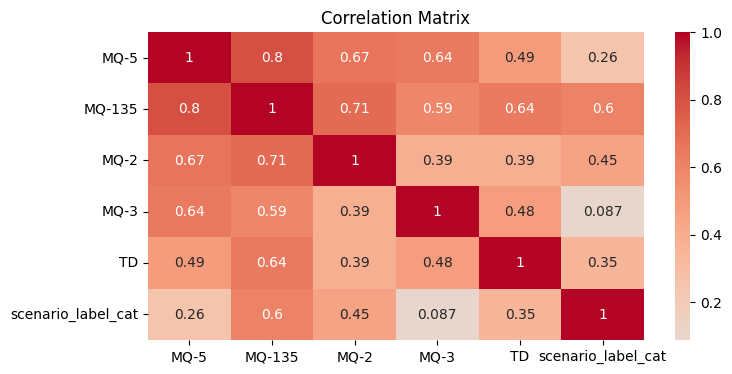

In [137]:
temp = data
corr_matrix = temp.drop('SCENARIO',axis=1).corr()
plt.figure(figsize=(8,4))
sn.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### **Importing sklearn for the baseline models:**

A logistic regression classifier\
A decision tree classifier\
A kneighbors classifier

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.neighbors import KNeighborsClassifier

Splitting the dataset into training and testing splits with 80:20 ratio

In [159]:
from sklearn.model_selection import train_test_split
X = data.drop(['scenario_label_cat','SCENARIO'],axis=1)
y = data['scenario_label_cat']
X_train, X_test, y_train, y_test = train_test_split(X,y_one_hot,test_size=.2,random_state=21)

Training a logistic regression model with a combination of l1 and l2 regularization/penalty

In [160]:
log_reg = LogisticRegression(solver='saga',penalty='elasticnet',max_iter=500,l1_ratio=.5)
log_reg.fit(X_train,y_train)

ValueError: y should be a 1d array, got an array of shape (620, 3) instead.

Testing the trained logistic regression model on the testing dataset

In [141]:
log_reg.score(X_test,y_test)

0.5

Training a decision tree model

In [142]:
tree_clfr = DecisionTreeClassifier()
tree_clfr.fit(X_train,y_train)

DecisionTreeClassifier()

Testing the trained decision tree model on the testing dataset

In [143]:
tree_clfr.score(X_test,y_test)

0.9871794871794872

Training a k-neighbors model using 8 neighbors

In [144]:
knn_clfr = KNeighborsClassifier(n_neighbors=8)
knn_clfr.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=8)

Testing the trained k-neighbors model on the testing dataset

In [145]:
knn_clfr.score(X_test,y_test)

0.9615384615384616

### **Importing tensorflow for the neural network model**

In [161]:
import tensorflow as tf;
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import metrics
from tensorflow.keras.utils import to_categorical

Using a simple neural network with 3 fully connected inner layers\
with 64,128, and 256 units, all with relu activation\
The output layer is a fully connected layer with softmax activation 

In [162]:
n_classes = data['SCENARIO'].nunique()

nn_clfr = Sequential([
    Dense(64,activation='relu',input_shape=[5]),
    Dense(128,activation='relu',),
    Dense(256,activation='relu'),
    Dense(n_classes,activation='softmax')]
)

Getting a summary of the neural network's architecture

In [148]:
nn_clfr.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 64)                384       
                                                                 
 dense_25 (Dense)            (None, 128)               8320      
                                                                 
 dense_26 (Dense)            (None, 256)               33024     
                                                                 
 dense_27 (Dense)            (None, 3)                 771       
                                                                 
Total params: 42499 (166.01 KB)
Trainable params: 42499 (166.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Training the neural network for 25 iterations/epochs\
using sparse categorical cross entropy loss\
and the Adaptive Moment Estimation (Adam) optimizer

In [164]:
nn_clfr.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy',metrics.Precision(), metrics.Recall()]
)

nn_history = nn_clfr.fit(X_train,y_train,epochs=25,batch_size=64,validation_data=[X_test,y_test])

Epoch 1/25
10/10 [==============================] - 3s 45ms/step - loss: 1.2623 - accuracy: 0.4935 - precision_11: 0.7147 - recall_8: 0.3839 - val_loss: 0.8563 - val_accuracy: 0.8141 - val_precision_11: 0.8442 - val_recall_8: 0.4167
Epoch 2/25
10/10 [==============================] - 0s 9ms/step - loss: 0.8615 - accuracy: 0.7484 - precision_11: 0.7718 - recall_8: 0.5290 - val_loss: 0.7470 - val_accuracy: 0.7436 - val_precision_11: 0.7638 - val_recall_8: 0.6218
Epoch 3/25
10/10 [==============================] - 0s 22ms/step - loss: 0.6034 - accuracy: 0.7806 - precision_11: 0.8449 - recall_8: 0.6855 - val_loss: 0.5623 - val_accuracy: 0.8013 - val_precision_11: 0.8696 - val_recall_8: 0.6410
Epoch 4/25
10/10 [==============================] - 0s 10ms/step - loss: 0.4917 - accuracy: 0.8435 - precision_11: 0.8872 - recall_8: 0.7355 - val_loss: 0.4319 - val_accuracy: 0.8782 - val_precision_11: 0.8947 - val_recall_8: 0.7628
Epoch 5/25
10/10 [==============================] - 0s 9ms/step - los

Text(0.5, 1.0, 'Training and Validation Accuracy')

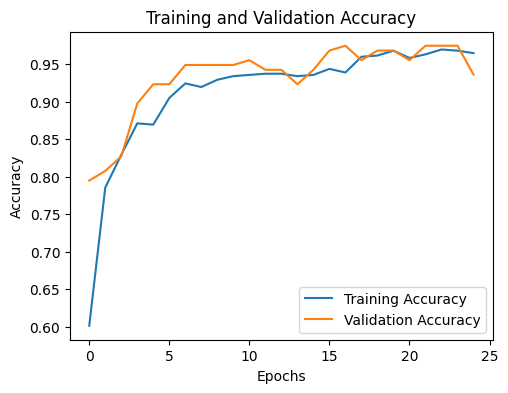

In [44]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(nn_history.history['accuracy'], label='Training Accuracy')
plt.plot(nn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

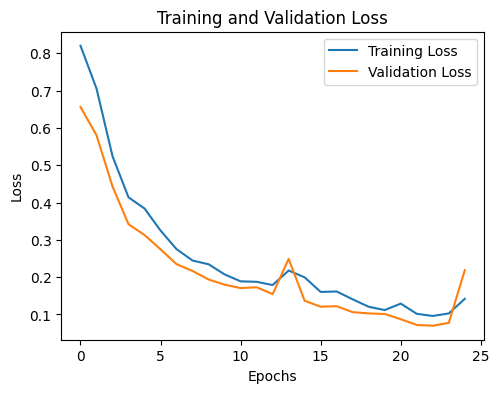

In [45]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(nn_history.history['loss'], label='Training Loss')
plt.plot(nn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [46]:
nn_clfr.evaluate(X_test,y_test)

5/5 [==============================] - 0s 5ms/step - loss: 0.2186 - accuracy: 0.9359


[0.21856781840324402, 0.9358974099159241]

### **Importing sklearn for the ensemble models**

In [47]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import seaborn as sns

Using a bagging ensemble technique by training a random forest classifier with 50 decision trees

In [48]:
rf_clfr = RandomForestClassifier(n_estimators=50)
rf_clfr.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50)

Testing the trained random forest classifier

In [49]:
rf_clfr.score(X_test,y_test)

0.9935897435897436

In [50]:
from sklearn.tree import export_graphviz
from graphviz import Source

# Select a single tree from the Random Forest
estimator = rf_clfr.estimators_[0]  # Select the first tree

# Export the selected tree to a .dot file
export_graphviz(
    estimator,
    out_file='random_forest_tree.dot',
    feature_names=['MQ-5', 'MQ-135', 'MQ-2', 'MQ-3', 'TD'],  # Replace with your feature names
    class_names=sorted(data['SCENARIO'].unique()),  # Replace with your class names
    rounded=True,
    proportion=False,
    precision=2,
    filled=True
)

# Load the .dot file and convert it to PNG
dot_data = open('random_forest_tree.dot').read()
graph = Source(dot_data)
graph.render('random_forest_tree', format='png', cleanup=True)

'random_forest_tree.png'

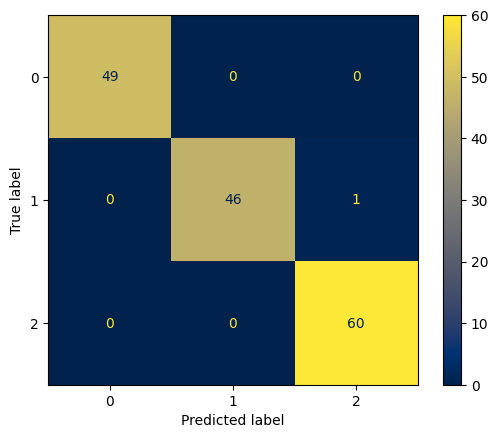

In [51]:
y_true= y_test
y_pred= rf_clfr.predict(X_test)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.cividis)
plt.show()

In [67]:
precision = precision_score(y_test, y_pred, average='macro')  # 'macro' for multi-class
recall = recall_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9892
Recall: 0.9858


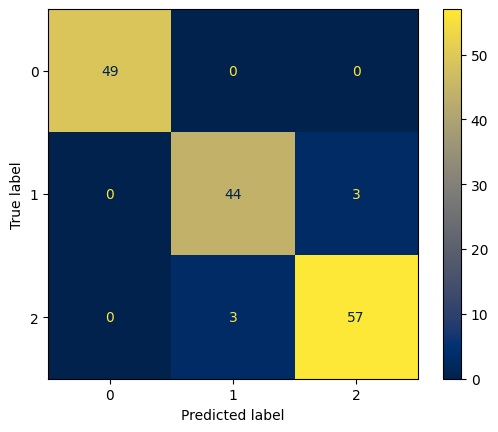

In [69]:
y_true= y_test
y_pred= knn_clfr.predict(X_test)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.cividis)
plt.show()

In [70]:
precision = precision_score(y_test, y_pred, average='macro')  # 'macro' for multi-class
recall = recall_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9621
Recall: 0.9621


Using a boosting ensemble technique by training a gradient boosting classifier and extreme gradient boosting classifier

In [54]:
gb_clfr = GradientBoostingClassifier()
gb_clfr.fit(X_train,y_train)

xgb_clfr = XGBClassifier()
xgb_clfr.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

Testing the trained gradient boosting classifier

In [55]:
gb_clfr.score(X_test,y_test)

0.9871794871794872

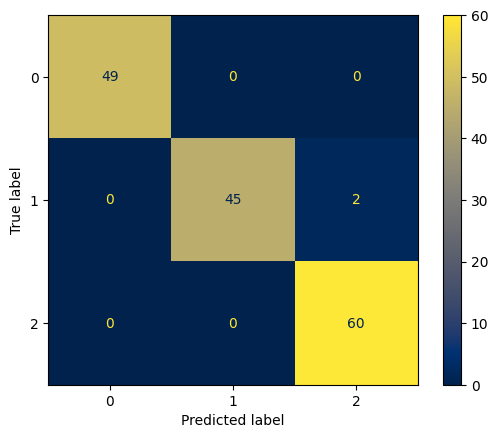

In [56]:
y_true= y_test
y_pred= gb_clfr.predict(X_test)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.cividis)
plt.show()

Testing the trained xgboost classifer

In [57]:
xgb_clfr.score(X_test,y_test)

1.0

Using a stacking ensemble technique that trains multiple base models:\
--- a decision tree classifier and\
--- a k-neighbors classifier\
and then trains a logistic regression classifier to classify\
based on the predictions of the base models

In [58]:
stack_clfr = StackingClassifier(estimators=[
    ('decision_tree',DecisionTreeClassifier()),
    ('k_neighbors',KNeighborsClassifier()),
],final_estimator=LogisticRegression(max_iter=100),n_jobs=3)

stack_clfr.fit(X_train,y_train)

StackingClassifier(estimators=[('decision_tree', DecisionTreeClassifier()),
                               ('k_neighbors', KNeighborsClassifier())],
                   final_estimator=LogisticRegression(), n_jobs=3)

Testing the trained stacking classifier 

In [59]:
stack_clfr.score(X_test,y_test)

0.9871794871794872

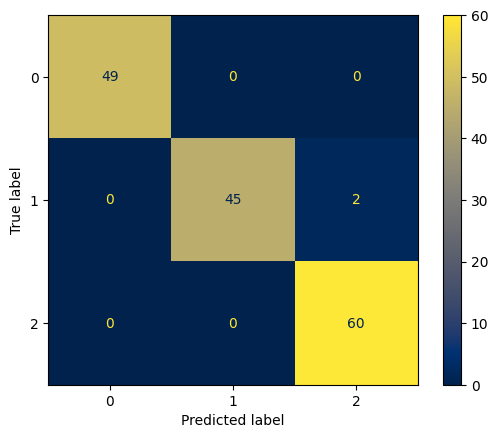

In [60]:
y_true= y_test
y_pred= stack_clfr.predict(X_test)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.cividis)
plt.show()

### **Visualizing the decision tree model**

In [61]:
from sklearn import tree

In [62]:
tree.export_graphviz(tree_clfr,
                     out_file='decision_tree_viz.dot',
                     feature_names=['MQ-5','MQ-135','MQ-2','MQ-3','TD'],
                     class_names=sorted(data['SCENARIO'].unique()),
                     label='all',
                     rounded=True,
                     filled=True
                     )


### **Saving all the models**

In [63]:
import joblib

In [64]:
joblib.dump(log_reg,'logistic_regression.pkl')
joblib.dump(tree_clfr,'decision_tree.pkl')
joblib.dump(knn_clfr,'k_neighbors.pkl')
joblib.dump(rf_clfr,'random_forest.pkl')
joblib.dump(gb_clfr,'gradient_boost.pkl')
joblib.dump(xgb_clfr,'x_gradient_boost.pkl')
joblib.dump(stack_clfr,'stacking.pkl')
nn_clfr.save('neural_network.keras')

### **Accuracy Metrics**
Logistic Regression : 0.5\
Decision Tree : 0.9807692307692307\
KNeighbors : 0.9615384615384616\
Random Forest : 0.9935897435897436\
Gradient Boosting : 0.9871794871794872\
Extreme Gradient Boosting : 1.0\
Stacking : 0.9871794871794872\
Neural Network : 0.9807692170143127